In [7]:
!curl -L -o adult.data https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
!curl -L -o adult.names https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3881k    0 3881k    0     0  6637k      0 --:--:-- --:--:-- --:--:-- 6634k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5229    0  5229    0     0  31879      0 --:--:-- --:--:-- --:--:-- 32079


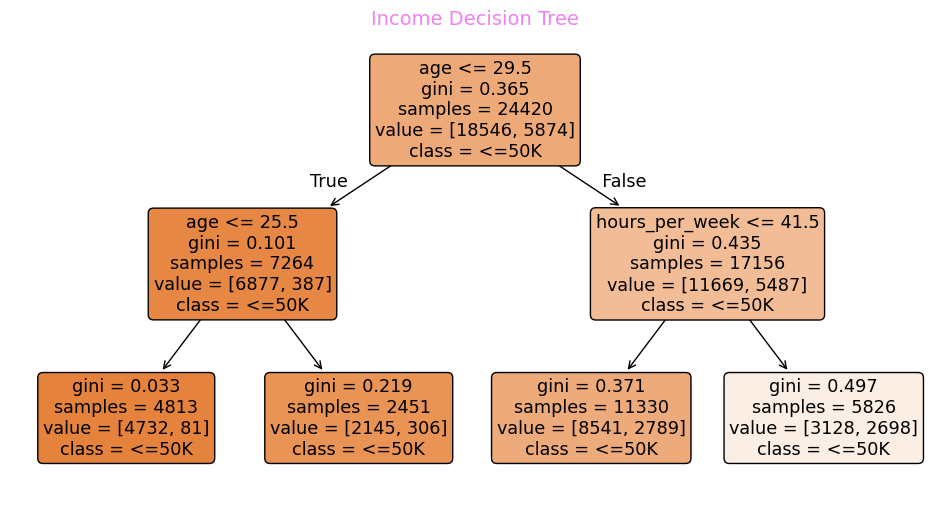

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

cols = ["age","workclass","fnlwgt","education","education_num",
        "marital_status","occupation","relationship","race","sex",
        "capital_gain","capital_loss","hours_per_week","native_country","income"]

df = pd.read_csv("adult.data", header=None, names=cols,
                 na_values=" ?", skipinitialspace=True)

# just tossing out rows with missing stuff
df = df.dropna()

# pick a few simple features (shuffled a bit)
X = df[["hours_per_week", "age"]]   # swapped order lol
y = df["income"]

# split data (different random_state so tree changes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)

# decision tree (gini instead of entropy, depth nudged)
clf = DecisionTreeClassifier(criterion="gini", max_depth=2, random_state=7)
clf.fit(X_train, y_train)

# plot tree in orange vibe
plt.figure(figsize=(12,6))
plot_tree(clf,
          feature_names=X.columns,
          class_names=clf.classes_,
          filled=True,
          rounded=True)
plt.title("Income Decision Tree", fontsize=14, color="orange")
plt.show()